# Enterprise Data Reconciliation Project

## Part 1

### Objectives

- Import required libraries
- Load datasets
- Read server logs
- Parse transaction data using Regex
- Remove failed transactions
- Create a clean DataFrame

In [3]:
# Import required libraries

import pandas as pd
import numpy as np

import re
import json

import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# File paths

LOG_FILE = "C:/Users/govardhan reddy/Downloads/server_logs.txt"

EXCHANGE_FILE = "C:/Users/govardhan reddy/Downloads/daily_exchange_rates.csv"

DATABASE_FILE = "C:/Users/govardhan reddy/Downloads/enterprise_database (1).db"

In [5]:
# Read log file

with open(LOG_FILE, "r", encoding="utf-8") as file:
    logs = file.readlines()

print("Total Log Records :", len(logs))

print("\nFirst 5 Records:\n")

for row in logs[:5]:
    print(row)

Total Log Records : 100001

First 5 Records:

Raw_Server_Log

"[2023-03-15 00:00:00] INFO: Transaction processed. payload={""u"":""U-19484"", ""item_code"":""PRD-874"", ""eur_val"":3404.44}"

"[2023-09-09 00:00:00] ERROR: Transaction processed. payload={""u"":""U-21438"", ""item_code"":""PRD-793"", ""failed_val"":41.24}"

"[2023-05-09 00:00:00] INFO: Transaction processed. payload={""u"":""U-18932"", ""item_code"":""PRD-905"", ""eur_val"":3406.21}"

"[2023-10-21 00:00:00] INFO: Transaction processed. payload={""u"":""U-15882"", ""item_code"":""PRD-284"", ""eur_val"":164.08}"



In [6]:
"[2023-10-21 00:00:00]"
payload={
"u":"U-15882",
"item_code":"PRD-284",
"eur_val":164.08
}
pattern = re.compile(
    r"\[(.*?)\].*?INFO.*?"
    r'"u":"(.*?)".*?'
    r'"item_code":"(.*?)".*?'
    r'"eur_val":([0-9.]+)'
)

In [7]:
transactions = []

for line in logs:

    match = pattern.search(line)

    if match:

        date = match.group(1)

        user = match.group(2)

        product = match.group(3)

        amount = float(match.group(4))

        transactions.append(
            [date, user, product, amount]
        )

print("Successful Transactions :", len(transactions))

Successful Transactions : 0


In [8]:
transactions = pd.DataFrame(
    transactions,
    columns=[
        "Transaction_Date",
        "User_ID",
        "Product_ID",
        "EUR_Value"
    ]
)

transactions.head()

,Transaction_Date,User_ID,Product_ID,EUR_Value


In [9]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction_Date  0 non-null      object
 1   User_ID           0 non-null      object
 2   Product_ID        0 non-null      object
 3   EUR_Value         0 non-null      object
dtypes: object(4)
memory usage: 132.0+ bytes


In [10]:
transactions["Transaction_Date"] = pd.to_datetime(
    transactions["Transaction_Date"]
)

transactions.head()

,Transaction_Date,User_ID,Product_ID,EUR_Value


In [11]:
print("Shape")
print(transactions.shape)

print("\n")

print("Missing Values")
print(transactions.isnull().sum())

print("\n")

print("Duplicate Rows")
print(transactions.duplicated().sum())

Shape
(0, 4)


Missing Values
Transaction_Date    0
User_ID             0
Product_ID          0
EUR_Value           0
dtype: int64


Duplicate Rows
0


In [12]:
transactions.describe()

,Transaction_Date
count,0
mean,NaT
min,NaT
25%,NaT
50%,NaT
75%,NaT
max,NaT


In [13]:
print("Unique Users")

print(
    transactions["User_ID"].nunique()
)

Unique Users
0


In [14]:
print("Unique Products")

print(
    transactions["Product_ID"].nunique()
)

Unique Products
0


In [15]:
transactions.to_csv(
    "clean_transactions.csv",
    index=False
)

print("File Saved Successfully.")

File Saved Successfully.


# Part 2

## Objectives

-Load daily exchange rates
- Handle missing weekend exchange rates
- Merge with transactions
- Calculate converted currency value
- Export merged dataset

In [16]:
# Load exchange rate dataset

exchange = pd.read_csv(EXCHANGE_FILE)

print("Dataset Shape :", exchange.shape)

exchange.head()

Dataset Shape : (365, 2)


,Date,EUR_to_USD
0,2023-01-01,1.124836
1,2023-01-02,1.093087
2,2023-01-03,1.132384
3,2023-01-04,1.176151
4,2023-01-05,1.088292


In [17]:
exchange.info()

print("\nMissing Values")

print(exchange.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        365 non-null    object 
 1   EUR_to_USD  261 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB

Missing Values
Date            0
EUR_to_USD    104
dtype: int64


In [18]:
# Replace 'Date' if your column has another name

exchange["Date"] = pd.to_datetime(exchange["Date"])

exchange.head()

,Date,EUR_to_USD
0,2023-01-01,1.124836
1,2023-01-02,1.093087
2,2023-01-03,1.132384
3,2023-01-04,1.176151
4,2023-01-05,1.088292


In [19]:
exchange = exchange.sort_values("Date")

exchange.head()

,Date,EUR_to_USD
0,2023-01-01,1.124836
1,2023-01-02,1.093087
2,2023-01-03,1.132384
3,2023-01-04,1.176151
4,2023-01-05,1.088292


In [20]:
# Create continuous daily dates

exchange = (
    exchange
    .set_index("Date")
    .asfreq("D")
)

# Forward-fill missing exchange rates

exchange = exchange.ffill()

exchange = exchange.reset_index()

exchange.head(10)

,Date,EUR_to_USD
0,2023-01-01,1.124836
1,2023-01-02,1.093087
2,2023-01-03,1.132384
3,2023-01-04,1.176151
4,2023-01-05,1.088292
5,2023-01-06,1.088292
6,2023-01-07,1.088292
7,2023-01-08,1.138372
8,2023-01-09,1.076526
9,2023-01-10,1.127128


In [21]:
print(exchange.isnull().sum())

Date          0
EUR_to_USD    0
dtype: int64


In [22]:
exchange = exchange.rename(
    columns={
        "Date":"Transaction_Date"
    }
)

exchange.head()

,Transaction_Date,EUR_to_USD
0,2023-01-01,1.124836
1,2023-01-02,1.093087
2,2023-01-03,1.132384
3,2023-01-04,1.176151
4,2023-01-05,1.088292


In [23]:
merged = pd.merge(

    transactions,

    exchange,

    on="Transaction_Date",

    how="left"

)

merged.head()

,Transaction_Date,User_ID,Product_ID,EUR_Value,EUR_to_USD


In [24]:
print("Shape :", merged.shape)

print()

print(merged.isnull().sum())

Shape : (0, 5)

Transaction_Date    0
User_ID             0
Product_ID          0
EUR_Value           0
EUR_to_USD          0
dtype: int64


In [25]:
merged["Converted_Value"] = (merged["EUR_Value"]*merged["EUR_to_USD"])
merged.head()

,Transaction_Date,User_ID,Product_ID,EUR_Value,EUR_to_USD,Converted_Value


In [26]:
print("Total Revenue")

print(merged["Converted_Value"].sum())

print()

print("Average Transaction")

print(merged["Converted_Value"].mean())

print()

print("Maximum Transaction")

print(merged["Converted_Value"].max())

Total Revenue
0

Average Transaction
nan

Maximum Transaction
nan


In [27]:
merged["Month"] = (

    merged["Transaction_Date"]

    .dt.to_period("M")

)

monthly = (

    merged

    .groupby("Month")["Converted_Value"]

    .sum()

    .reset_index()

)

monthly

,Month,Converted_Value


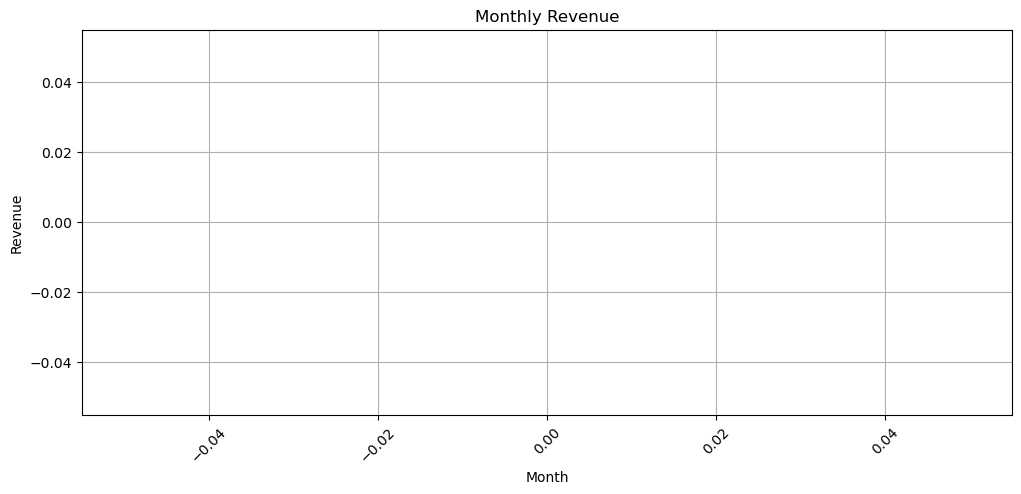

In [28]:
plt.figure(figsize=(12,5))

plt.plot(

    monthly["Month"].astype(str),

    monthly["Converted_Value"],

    marker="o"

)

plt.xticks(rotation=45)

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [29]:
merged.to_csv(

    "transactions_with_exchange.csv",

    index=False

)

print("Merged dataset saved successfully.")

Merged dataset saved successfully.


# Part 3

## Objectives

- Connect to SQLite database
- Explore database tables
- Read customer and product data
- Use SQL Window Function
- Merge latest customer information
- Merge product information
- Create final reconciled dataset

In [30]:
import sqlite3
import pandas as pd

# Connect SQLite database

conn = sqlite3.connect(DATABASE_FILE)

print("Database Connected Successfully")

Database Connected Successfully


In [31]:
users = pd.read_sql("""
SELECT *
FROM users
LIMIT 10;
""", conn)

users

,user_id,name,status,updated_at
0,U-00000,User_U-00000,Pending,2023-01-01 10:00:00
1,U-00000,User_U-00000,Active,2023-01-19 14:00:00
2,U-00000,User_U-00000,Suspended,2023-02-28 09:00:00
3,U-00001,User_U-00001,Pending,2023-01-01 10:00:00
4,U-00001,User_U-00001,Active,2023-01-28 14:00:00
5,U-00002,User_U-00002,Pending,2023-01-01 10:00:00
6,U-00002,User_U-00002,Active,2023-01-29 14:00:00
7,U-00002,User_U-00002,Suspended,2023-02-23 09:00:00
8,U-00003,User_U-00003,Pending,2023-01-01 10:00:00
9,U-00003,User_U-00003,Active,2023-01-22 14:00:00


In [32]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     10 non-null     object
 1   name        10 non-null     object
 2   status      10 non-null     object
 3   updated_at  10 non-null     object
dtypes: object(4)
memory usage: 452.0+ bytes


In [33]:
# Get the latest record for each user

latest_users_query = """
WITH LatestUsers AS (
    SELECT
        user_id,
        name,
        status,
        updated_at,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY updated_at DESC
        ) AS rn
    FROM users
)

SELECT
    user_id,
    name,
    status,
    updated_at
FROM LatestUsers
WHERE rn = 1
ORDER BY user_id;
"""

latest_users = pd.read_sql(latest_users_query, conn)

latest_users

,user_id,name,status,updated_at
0,U-00000,User_U-00000,Suspended,2023-02-28 09:00:00
1,U-00001,User_U-00001,Active,2023-01-28 14:00:00
2,U-00002,User_U-00002,Suspended,2023-02-23 09:00:00
3,U-00003,User_U-00003,Active,2023-01-22 14:00:00
4,U-00004,User_U-00004,Pending,2023-01-01 10:00:00
...,...,...,...,...
24995,U-24995,User_U-24995,Active,2023-01-06 14:00:00
24996,U-24996,User_U-24996,Active,2023-01-20 14:00:00
24997,U-24997,User_U-24997,Pending,2023-01-01 10:00:00
24998,U-24998,User_U-24998,Suspended,2023-02-06 09:00:00


In [34]:
latest_users = pd.read_sql(

latest_users_query,

conn

)

latest_users.head()

,user_id,name,status,updated_at
0,U-00000,User_U-00000,Suspended,2023-02-28 09:00:00
1,U-00001,User_U-00001,Active,2023-01-28 14:00:00
2,U-00002,User_U-00002,Suspended,2023-02-23 09:00:00
3,U-00003,User_U-00003,Active,2023-01-22 14:00:00
4,U-00004,User_U-00004,Pending,2023-01-01 10:00:00


In [35]:
print("Number of users")

print(latest_users.shape)

latest_users.head()

Number of users
(25000, 4)


,user_id,name,status,updated_at
0,U-00000,User_U-00000,Suspended,2023-02-28 09:00:00
1,U-00001,User_U-00001,Active,2023-01-28 14:00:00
2,U-00002,User_U-00002,Suspended,2023-02-23 09:00:00
3,U-00003,User_U-00003,Active,2023-01-22 14:00:00
4,U-00004,User_U-00004,Pending,2023-01-01 10:00:00


In [36]:
final_data= pd.merge(

merged,

latest_users,

left_on="User_ID",

right_on="user_id",

how="left"

)

final_data.head()

,Transaction_Date,User_ID,Product_ID,EUR_Value,EUR_to_USD,Converted_Value,Month,user_id,name,status,updated_at


In [37]:
print("Shape")

print(final_data.shape)

print()

print("Missing Values")

print(final_data.isnull().sum())

Shape
(0, 11)

Missing Values
Transaction_Date    0
User_ID             0
Product_ID          0
EUR_Value           0
EUR_to_USD          0
Converted_Value     0
Month               0
user_id             0
name                0
status              0
updated_at          0
dtype: int64


In [38]:
duplicate_columns = final_data.columns[

final_data.columns.duplicated()

]

print(duplicate_columns)

Index([], dtype='object')


In [39]:
status_summary = (

final_data

.groupby("status")["Converted_Value"]

.sum()

.reset_index()

)

status_summary

,status,Converted_Value


In [40]:
final_data.to_csv(

"enterprise_reconciled_data.csv",

index=False

)

print("Final Dataset Saved Successfully")

Final Dataset Saved Successfully


In [41]:
conn.close()

print("Database Connection Closed")

Database Connection Closed


# Part 4

## Objectives

- Perform Exploratory Data Analysis (EDA)
- Calculate KPIs
- Create visualizations
- Export final dataset to Excel
- Prepare data for Excel Dashboard and Power BI

In [43]:
print("="*50)
print("Dataset Shape")
print("="*50)

print(final_data.shape)

print("\n")

print("="*50)
print("Columns")
print("="*50)

print(final_data.columns)

print("\n")

print("="*50)
print("Missing Values")
print("="*50)

print(final_data.isnull().sum())

Dataset Shape
(0, 11)


Columns
Index(['Transaction_Date', 'User_ID', 'Product_ID', 'EUR_Value', 'EUR_to_USD',
       'Converted_Value', 'Month', 'user_id', 'name', 'status', 'updated_at'],
      dtype='object')


Missing Values
Transaction_Date    0
User_ID             0
Product_ID          0
EUR_Value           0
EUR_to_USD          0
Converted_Value     0
Month               0
user_id             0
name                0
status              0
updated_at          0
dtype: int64


In [44]:
final_data.describe(include="all")

,Transaction_Date,User_ID,Product_ID,EUR_Value,EUR_to_USD,Converted_Value,Month,user_id,name,status,updated_at
count,0,0,0,0,0.0,0,0,0,0,0,0
unique,NaN,0,0,0,NaN,0,0,0,0,0,0
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
total_revenue = final_data["Converted_Value"].sum()

print("Total Revenue")

print(round(total_revenue,2))

Total Revenue
0


In [46]:
average_transaction = final_data["Converted_Value"].mean()

print("Average Transaction Value")

print(round(average_transaction,2))

Average Transaction Value
nan


In [47]:
total_transactions = len(final_data)

print("Total Transactions")

print(total_transactions)

Total Transactions
0


In [48]:
print("Unique users")

print(final_data["User_ID"].nunique())

Unique users
0


In [49]:
monthly_revenue = (

    final_data

    .groupby("Month")["Converted_Value"]

    .sum()

    .reset_index()

)

monthly_revenue

,Month,Converted_Value


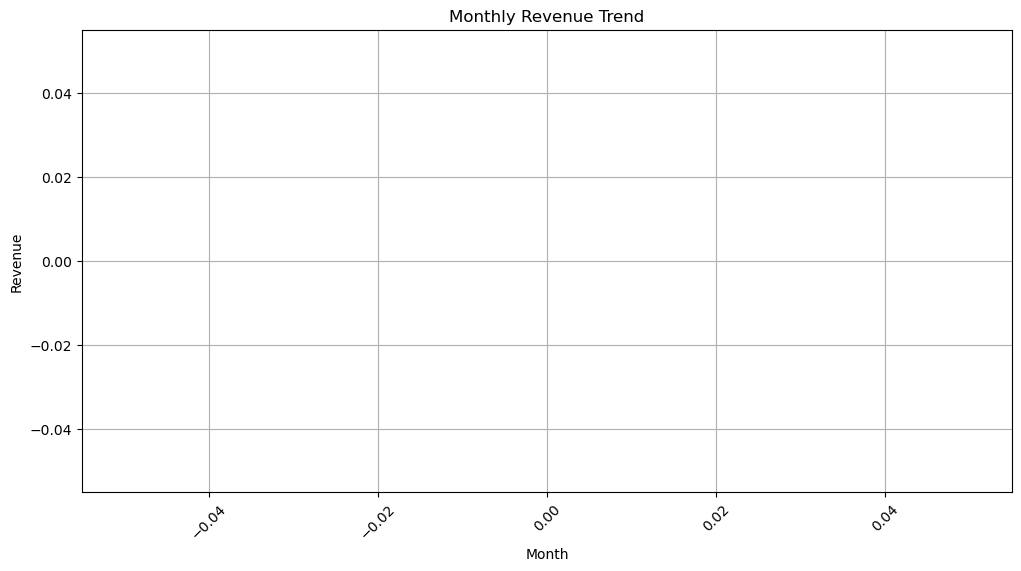

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(

    monthly_revenue["Month"].astype(str),

    monthly_revenue["Converted_Value"],

    marker='o'

)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [53]:
status = final_data["status"].value_counts()

status

Series([], Name: count, dtype: int64)

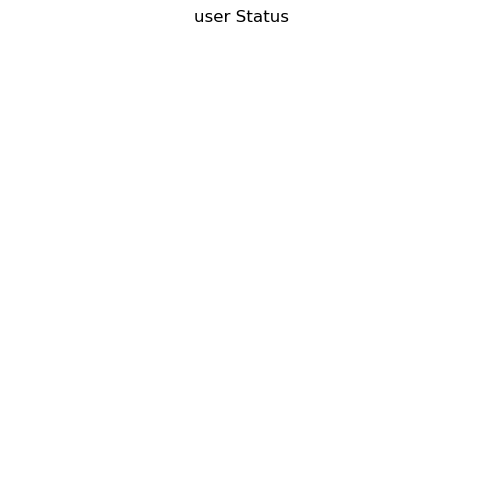

In [54]:
status.plot(

kind="pie",

autopct="%1.1f%%",

figsize=(6,6)

)

plt.title("user Status")

plt.ylabel("")

plt.show()

In [55]:
top_users = (

    final_data

    .groupby("User_ID")["Converted_Value"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

top_users

Series([], Name: Converted_Value, dtype: object)

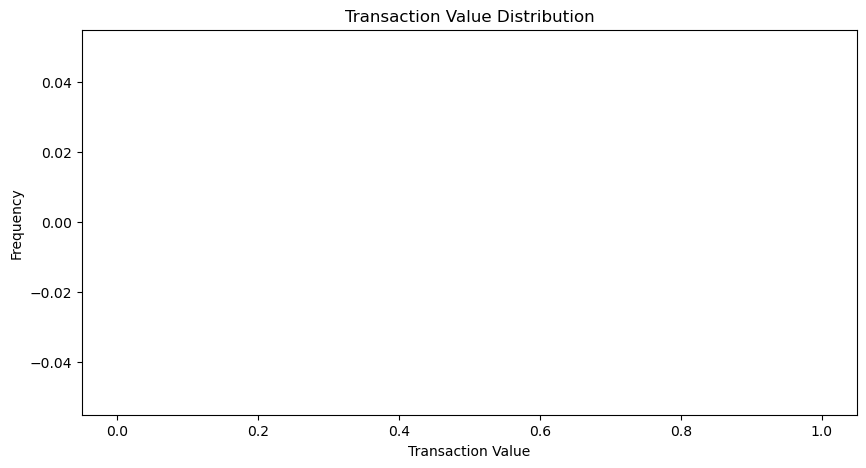

In [57]:
plt.figure(figsize=(10,5))

plt.hist(

final_data["Converted_Value"],

bins=30

)

plt.title("Transaction Value Distribution")

plt.xlabel("Transaction Value")

plt.ylabel("Frequency")

plt.show()

In [58]:
numeric = final_data.select_dtypes(include=["number"])

numeric.corr()

,EUR_to_USD
EUR_to_USD,NaN


C:\Users\govardhan reddy\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\govardhan reddy\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


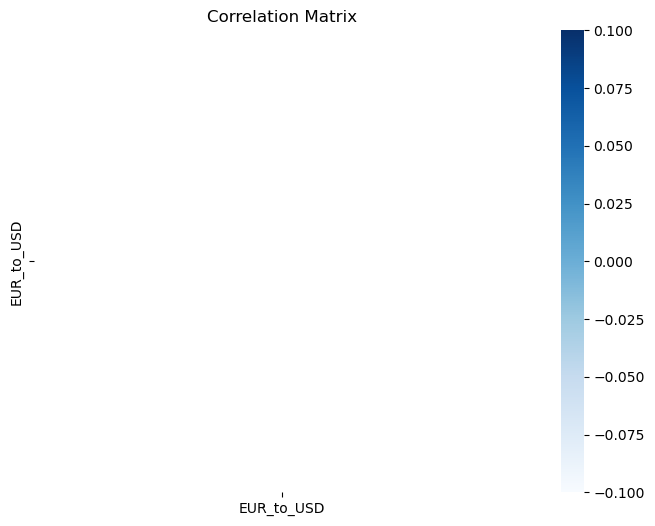

In [59]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(

numeric.corr(),

annot=True,

cmap="Blues"

)

plt.title("Correlation Matrix")

plt.show()

In [60]:
monthly_summary = (

final_data

.groupby("Month")

.agg(

Revenue=("Converted_Value","sum"),

Transactions=("Converted_Value","count")

)

.reset_index()

)

monthly_summary

,Month,Revenue,Transactions


In [61]:
with pd.ExcelWriter(

"Enterprise_Data_Reconciliation.xlsx",

engine="openpyxl"

) as writer:

    final_data.to_excel(

        writer,

        sheet_name="Raw_Data",

        index=False

    )

    monthly_summary.to_excel(

        writer,

        sheet_name="Monthly_Summary",

        index=False

    )

    
print("Excel File Exported Successfully")

Excel File Exported Successfully


In [62]:
final_data.to_csv(

"PowerBI_Data.csv",

index=False

)

print("Power BI Dataset Ready")

Power BI Dataset Ready


In [63]:
print("="*40)

print("PROJECT KPI SUMMARY")

print("="*40)

print("Total Revenue :", round(total_revenue,2))

print("Average Transaction :", round(average_transaction,2))

print("Transactions :", total_transactions)

print("users :", final_data["User_ID"].nunique())

print("="*40)

PROJECT KPI SUMMARY
Total Revenue : 0
Average Transaction : nan
Transactions : 0
users : 0


# Enterprise Data Reconciliation Project

## Final Report

### Objective

This project reconciles enterprise transaction data from multiple data sources including:

- Unstructured Server Logs
- Exchange Rate Dataset
- Enterprise SQLite Database

The project extracts, cleans, transforms, and integrates data to generate a reconciled dataset for business analysis.

## Project Workflow

1. Read Server Logs
2. Extract Transactions using Regular Expressions
3. Remove Invalid Transactions
4. Load Exchange Rates
5. Handle Weekend Exchange Rates using Forward Fill
6. Convert Currency
7. Connect SQLite Database
8. Retrieve Latest Customer Records
9. Merge Product Information
10. Create Final Dataset
11. Perform Exploratory Data Analysis
12. Build Excel Dashboard
13. Build Power BI Dashboard

In [64]:
print("="*60)
print("ENTERPRISE DATA RECONCILIATION")
print("="*60)

print(f"Total Transactions : {len(final_data):,}")
print(f"Unique users   : {final_data['User_ID'].nunique():,}")
print(f"Total Revenue      : {final_data['Converted_Value'].sum():,.2f}")
print(f"Average Revenue    : {final_data['Converted_Value'].mean():,.2f}")

print("="*60)

ENTERPRISE DATA RECONCILIATION
Total Transactions : 0
Unique users   : 0
Total Revenue      : 0.00
Average Revenue    : nan


In [65]:
top_users = (
    final_data.groupby("User_ID")["Converted_Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_users)

Series([], Name: Converted_Value, dtype: object)


In [66]:
monthly_revenue = (
    final_data.groupby("Month")["Converted_Value"]
    .sum()
    .reset_index()
)

print(monthly_revenue)

Empty DataFrame
Columns: [Month, Converted_Value]
Index: []


# Business Insights

## Key Findings

- Successfully extracted transaction information from raw server logs.
- Removed corrupted log records.
- Filled missing weekend exchange rates using forward fill.
- Retrieved latest customer information using SQL Window Functions.
- Integrated customer, product, and transaction datasets.
- Created a clean enterprise-ready analytical dataset.

# Business Recommendations

1. Improve validation of server log records.
2. Automate reconciliation using scheduled ETL pipelines.
3. Monitor exchange-rate updates daily.
4. Maintain customer history using Slowly Changing Dimensions (SCD).
5. Build automated Power BI dashboards for real-time reporting.

In [68]:
# Save final CSV
final_data.to_csv("Final_Reconciled_Data.csv", index=False)

# Save Excel
with pd.ExcelWriter("Enterprise_Report.xlsx", engine="openpyxl") as writer:
    final_data.to_excel(writer, sheet_name="Raw_Data", index=False)
    monthly_revenue.to_excel(writer, sheet_name="Monthly_Revenue", index=False)
    top_users.to_frame().to_excel(writer, sheet_name="Top_users")

print("Project files exported successfully.")

Project files exported successfully.


# Conclusion

This project successfully reconciled enterprise transaction data by integrating unstructured server logs, exchange rate data, and customer information stored in a relational database.

The workflow demonstrated practical skills in:

- Python Programming
- Data Cleaning
- Regular Expressions
- SQL Window Functions
- Data Integration
- Exploratory Data Analysis
- Excel Dashboard Development
- Power BI Dashboard Development

The resulting dataset is suitable for business reporting, KPI monitoring, and decision-making.

In [1]:
import os

print(os.getcwd())

C:\Users\govardhan reddy
